# 01 — Exploration et nettoyage des données

## Projet : Online Shoppers Purchase Intention

Ce notebook sert à :

1. charger le fichier ;
2. comprendre sa structure ;
3. vérifier sa qualité ;
4. faire un nettoyage simple ;
5. réaliser une première exploration ;
6. exporter un fichier propre pour la suite du projet.

Le code reste volontairement simple et facile à comprendre.

## 1. Importer les bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2. Charger le fichier

In [2]:
from pathlib import Path

# The notebook can be run from the repository root or from the notebooks folder.
current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

file_path = project_root / "data" / "raw" / "online_shoppers_intention.csv"

df = pd.read_csv(file_path)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Comprendre la structure du dataset

In [3]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 12330
Nombre de colonnes : 18


In [4]:
print("Liste des colonnes :")
print(df.columns.tolist())

Liste des colonnes :
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

## 4. Vérifier la qualité des données

### 4.1 Valeurs manquantes

In [6]:
missing_values = df.isnull().sum()

missing_values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
print("Nombre total de valeurs manquantes :", df.isnull().sum().sum())

Nombre total de valeurs manquantes : 0


### 4.2 Lignes identiques

In [8]:
duplicate_rows = df.duplicated().sum()

print("Nombre de lignes parfaitement identiques :", duplicate_rows)

Nombre de lignes parfaitement identiques : 125


**Décision :** nous ne supprimons pas automatiquement ces lignes.

Le dataset ne contient pas d'identifiant unique de session. Deux sessions différentes peuvent donc avoir exactement les mêmes valeurs. Les supprimer sans preuve pourrait fausser l'analyse.

### 4.3 Statistiques générales

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


### 4.4 Valeurs des colonnes catégorielles

In [10]:
print("Mois :", df["Month"].unique())
print()
print("Types de visiteurs :", df["VisitorType"].unique())
print()
print("Weekend :", df["Weekend"].unique())
print()
print("Revenue :", df["Revenue"].unique())

Mois : ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

Types de visiteurs : ['Returning_Visitor' 'New_Visitor' 'Other']

Weekend : [False  True]

Revenue : [False  True]


### 4.5 Vérifier les valeurs négatives

In [11]:
numeric_columns = df.select_dtypes(include="number").columns

negative_values = (df[numeric_columns] < 0).sum()

negative_values

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
dtype: int64

## 5. Nettoyage simple

In [12]:
# Créer une copie pour garder les données originales intactes
df_clean = df.copy()

### 5.1 Mettre les noms des colonnes en minuscules

In [13]:
df_clean.columns = df_clean.columns.str.strip().str.lower()

df_clean.columns.tolist()

['administrative',
 'administrative_duration',
 'informational',
 'informational_duration',
 'productrelated',
 'productrelated_duration',
 'bouncerates',
 'exitrates',
 'pagevalues',
 'specialday',
 'month',
 'operatingsystems',
 'browser',
 'region',
 'traffictype',
 'visitortype',
 'weekend',
 'revenue']

### 5.2 Uniformiser les valeurs texte

In [14]:
# Retirer les espaces inutiles
df_clean["month"] = df_clean["month"].str.strip()
df_clean["visitortype"] = df_clean["visitortype"].str.strip()

# Utiliser la même forme courte pour tous les mois
df_clean["month"] = df_clean["month"].replace({"June": "Jun"})

# Rendre le type de visiteur plus lisible
df_clean["visitortype"] = df_clean["visitortype"].str.replace("_", " ", regex=False)

print(df_clean["month"].unique())
print(df_clean["visitortype"].unique())

['Feb' 'Mar' 'May' 'Oct' 'Jun' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
['Returning Visitor' 'New Visitor' 'Other']


### 5.3 Ajouter le numéro du mois

In [15]:
month_order = {
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "Jun": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
}

df_clean["month_number"] = df_clean["month"].map(month_order)

df_clean[["month", "month_number"]].drop_duplicates().sort_values("month_number")

,month,month_number
0,Feb,2
184,Mar,3
2091,May,5
5456,Jun,6
5460,Jul,7
5462,Aug,8
5468,Sep,9
5455,Oct,10
5463,Nov,11
7982,Dec,12


### 5.4 Transformer les booléens en 0 et 1

In [16]:
df_clean["weekend"] = df_clean["weekend"].astype(int)
df_clean["revenue"] = df_clean["revenue"].astype(int)

df_clean[["weekend", "revenue"]].head()

,weekend,revenue
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0


### 5.5 Vérification finale

In [17]:
print("Dimensions finales :", df_clean.shape)
print("Valeurs manquantes :", df_clean.isnull().sum().sum())
print()
print(df_clean.dtypes)

Dimensions finales : (12330, 19)
Valeurs manquantes : 0

administrative               int64
administrative_duration    float64
informational                int64
informational_duration     float64
productrelated               int64
productrelated_duration    float64
bouncerates                float64
exitrates                  float64
pagevalues                 float64
specialday                 float64
month                       object
operatingsystems             int64
browser                      int64
region                       int64
traffictype                  int64
visitortype                 object
weekend                      int64
revenue                      int64
month_number                 int64
dtype: object


## 6. Première exploration des données

### 6.1 Répartition des achats

In [18]:
purchase_counts = df_clean["revenue"].value_counts().sort_index()

purchase_counts.index = ["Pas d'achat", "Achat"]
purchase_counts

Pas d'achat    10422
Achat           1908
Name: count, dtype: int64

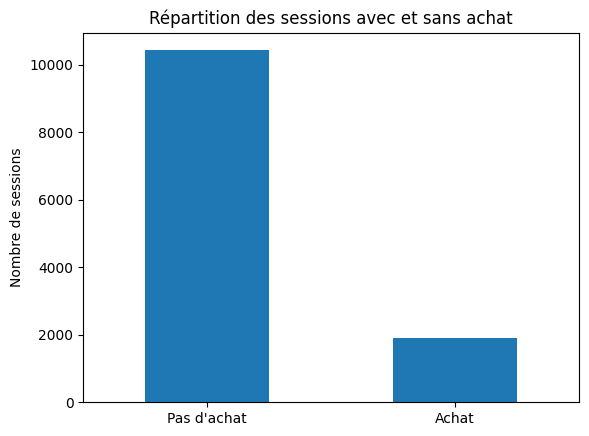

In [19]:
purchase_counts.plot(kind="bar")

plt.title("Répartition des sessions avec et sans achat")
plt.xlabel("")
plt.ylabel("Nombre de sessions")
plt.xticks(rotation=0)
plt.show()

### 6.2 Taux de conversion global

In [20]:
conversion_rate = df_clean["revenue"].mean() * 100

print("Taux de conversion global :", round(conversion_rate, 2), "%")

Taux de conversion global : 15.47 %


### 6.3 Taux de conversion par type de visiteur

In [21]:
conversion_by_visitor = (
    df_clean.groupby("visitortype")["revenue"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

conversion_by_visitor

visitortype
New Visitor          24.911452
Other                18.823529
Returning Visitor    13.932329
Name: revenue, dtype: float64

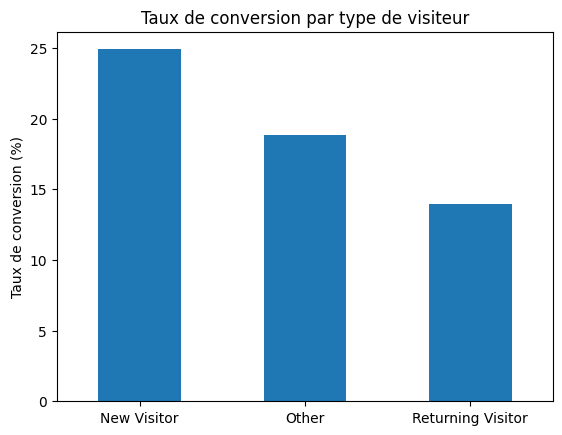

In [22]:
conversion_by_visitor.plot(kind="bar")

plt.title("Taux de conversion par type de visiteur")
plt.xlabel("")
plt.ylabel("Taux de conversion (%)")
plt.xticks(rotation=0)
plt.show()

### 6.4 Taux de conversion par mois

In [23]:
conversion_by_month = (
    df_clean.groupby(["month_number", "month"])["revenue"]
    .mean()
    .mul(100)
    .reset_index()
    .sort_values("month_number")
)

conversion_by_month

,month_number,month,revenue
0,2,Feb,1.630435
1,3,Mar,10.068170
2,5,May,10.850178
3,6,Jun,10.069444
4,7,Jul,15.277778
5,8,Aug,17.551963
6,9,Sep,19.196429
7,10,Oct,20.947177
8,11,Nov,25.350233
9,12,Dec,12.507238


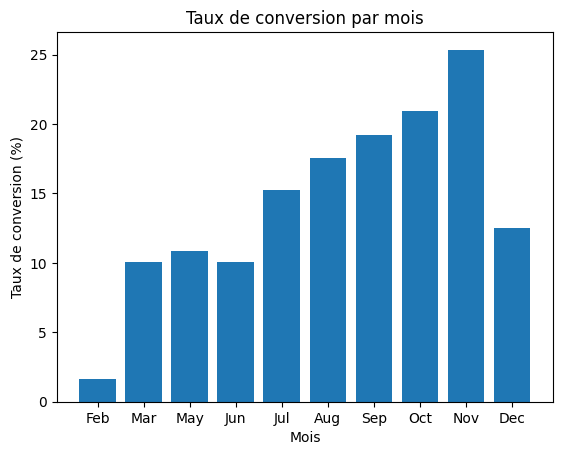

In [24]:
plt.bar(conversion_by_month["month"], conversion_by_month["revenue"])

plt.title("Taux de conversion par mois")
plt.xlabel("Mois")
plt.ylabel("Taux de conversion (%)")
plt.show()

### 6.5 Comparer les sessions avec et sans achat

In [25]:
session_comparison = df_clean.groupby("revenue")[
    [
        "administrative_duration",
        "informational_duration",
        "productrelated_duration",
        "bouncerates",
        "exitrates",
        "pagevalues"
    ]
].mean().round(2)

session_comparison.index = ["Pas d'achat", "Achat"]

session_comparison

,administrative_duration,informational_duration,productrelated_duration,bouncerates,exitrates,pagevalues
Pas d'achat,73.74,30.24,1069.99,0.03,0.05,1.98
Achat,119.48,57.61,1876.21,0.01,0.02,27.26


## 7. Exporter le fichier nettoyé

In [26]:
output_path = project_root / "data" / "processed" / "online_shoppers_cleaned.csv"

df_clean.to_csv(output_path, index=False)

print("Fichier nettoyé enregistré :", output_path)

Fichier nettoyé enregistré : /mnt/data/online-shoppers-conversion-analysis/data/processed/online_shoppers_cleaned.csv


## 8. Résumé du nettoyage

- Le fichier contient 12 330 sessions.
- Il n'y a aucune valeur manquante.
- Aucune valeur numérique négative n'a été détectée.
- Les noms des colonnes ont été uniformisés.
- Les valeurs texte ont été rendues plus cohérentes.
- Une colonne `month_number` a été ajoutée.
- `weekend` et `revenue` ont été transformées en 0 et 1.
- Les 125 lignes identiques ont été conservées, faute d'identifiant unique permettant de confirmer qu'il s'agit de doublons.